# Лабораторна робота №1. Попередній аналіз та підготовка даних
### Проєкт DocVerify — класифікація типу бізнес-документа та перевірка автентичності

У цьому notebook використано **реальні дані для 20 класів документів** (повний план Лаб.0),
завантажені повністю автоматично та відтворювано — див. **Секцію 0** нижче, де знаходиться
РЕАЛЬНИЙ код завантаження (Hugging Face `datasets` стрімінг, Kaggle REST API, пряме
FTP-з'єднання), а не лише посилання на нього. Notebook можна запустити з чистого стану:
кожне джерело завантажується автоматично, окрім одного одноразового ручного кроку —
налаштування облікових даних Kaggle (детально описано в Секції 0.3).

**Короткий підсумок джерел:**

| Клас(и) | К-сть | Джерело |
|---|---|---|
| рахунок, лист, форма, email, рукописний текст, реклама, науковий звіт, наукова публікація, специфікація, файлова папка, новинна стаття, бюджет, презентація, анкета, резюме, службова записка (16 класів) | 189-220 кожен | RVL-CDIP (мірор `jinhybr/rvl_cdip_400_train_val_test`, HF `datasets` streaming) |
| квитанція | 200 | CORD (`naver-clova-ix/cord-v2`, HF `datasets` streaming) |
| паспорт | 133 | 3 Kaggle-датасети синтетичних паспортів (CC BY-NC-ND 4.0) |
| ID-картка | 100 | Kaggle `hafidprasetyawan/dummy-image-ktp-indonesia` (MIT) |
| посвідчення водія | 180 | MIDV-500, FTP `smartengines.com` (Wikimedia Commons) |

Усього — **3682 зображення, 20 класів**. Детальні застереження щодо кожного джерела
(зокрема, що канадські паспорти й фінське посвідчення водія — це одна синтетична особа/шаблон
під різними умовами зйомки, а не багато різних людей) наведено в markdown-комірках Секції 0
та в підсумковому Висновку в кінці notebook.</cell id="3fa2901d">

In [1]:
# ==================== КОНФІГУРАЦІЙНИЙ БЛОК ====================
import os
DATA_DIR = "data/real"              # тека із зображеннями (підпапки = класи), РЕАЛЬНІ дані
METADATA_CSV = "data/metadata_real.csv"  # таблиця метаданих (РЕАЛЬНІ дані)
TARGET = "document_type"           # цільова змінна (тип документа)
AUTH_COLUMN = "authenticity"        # друга цільова змінна (автентичність, є не для всіх класів)
IMG_SIZE = (32, 32)                 # розмір, до якого приводяться зображення для X (k-NN, Лаб.2)
TEST_SIZE = 0.2
RANDOM_STATE = 42
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hashlib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

## 0. Завантаження вихідних даних

Ця секція містить ПОВНИЙ, реально виконуваний код, яким були отримані всі зображення в `data/real/`.
Жодних прихованих ручних кроків тут немає: кожна комірка або (а) завантажує дані сама, або (б) одразу
пропускає завантаження, якщо потрібні файли вже лежать на диску (перевірка робиться функцією
`already_downloaded()` нижче) — це робить весь notebook ідемпотентним і придатним для повторного запуску
без зайвого витрачання часу й трафіку.

Джерела даних (до 20 класів):

| Джерело | Спосіб доступу | Класи |
|---|---|---|
| RVL-CDIP (мірор `jinhybr/rvl_cdip_400_train_val_test`) | стрімінг Hugging Face `datasets`, без реєстрації | рахунок, лист, форма, email, рукописний текст, реклама, науковий звіт, наукова публікація, специфікація, файлова папка, новинна стаття, бюджет, презентація, анкета, резюме, службова записка (16 класів) |
| CORD (`naver-clova-ix/cord-v2`) | стрімінг Hugging Face `datasets`, без реєстрації | квитанція |
| Kaggle (3 датасети) | REST API з токеном — **потрібна одноразова реєстрація**, див. інструкцію нижче | паспорт |
| Kaggle (`hafidprasetyawan/dummy-image-ktp-indonesia`) | той самий Kaggle-токен | ID-картка |
| MIDV-500 (smartengines.com) | пряме FTP-з'єднання, без реєстрації | посвідчення водія |

**Спроба знайти класи «посвідчення водія» та «ID-картка» (план Лаб.0, 20 класів):** обидва джерела
знайдено й успішно використано — MIDV-500 (FTP) для посвідчення водія та Kaggle KTP-датасет для
ID-картки. Деталі та застереження — у відповідних markdown-комірках нижче.

In [2]:
# ---------- Допоміжні функції та реєстр класів ----------

def class_dir(folder):
    return os.path.join(DATA_DIR, folder)

def already_downloaded(folder, min_files=100):
    """Ідемпотентність: якщо потрібна кількість файлів вже є на диску — пропускаємо завантаження."""
    d = class_dir(folder)
    if not os.path.isdir(d):
        return False
    n = len([f for f in os.listdir(d) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return n >= min_files

# folder -> (document_type, source_dataset, authenticity за замовчуванням)
CLASS_INFO = {
    "rahunok":                ("рахунок",              "RVL-CDIP", ""),
    "lyst":                   ("лист",                 "RVL-CDIP", ""),
    "form":                   ("форма",                "RVL-CDIP", ""),
    "email":                  ("email",                "RVL-CDIP", ""),
    "handwritten":            ("рукописний текст",     "RVL-CDIP", ""),
    "advertisement":          ("реклама",              "RVL-CDIP", ""),
    "scientific_report":      ("науковий звіт",        "RVL-CDIP", ""),
    "scientific_publication": ("наукова публікація",   "RVL-CDIP", ""),
    "specification":          ("специфікація",         "RVL-CDIP", ""),
    "file_folder":            ("файлова папка",        "RVL-CDIP", ""),
    "news_article":           ("новинна стаття",       "RVL-CDIP", ""),
    "budget":                 ("бюджет",               "RVL-CDIP", ""),
    "presentation":           ("презентація",          "RVL-CDIP", ""),
    "questionnaire":          ("анкета",               "RVL-CDIP", ""),
    "resume":                 ("резюме",               "RVL-CDIP", ""),
    "memo":                   ("службова записка",     "RVL-CDIP", ""),
    "kvitanciya":             ("квитанція",            "SROIE/CORD", "genuine"),
    "pasport":                ("паспорт",              "Synthetic Passports Dataset (Kaggle)", "genuine"),
    "id_card":                ("ID-картка",            "Dummy KTP Indonesia (Kaggle)", ""),
    "drvlic":                 ("посвідчення водія",    "MIDV-500 (Wikimedia Commons, FTP smartengines.com)", ""),
}

# відповідність міток RVL-CDIP (Hugging Face) -> назва теки проєкту
RVL_HF_LABEL_MAP = {
    "invoice": "rahunok",
    "letter": "lyst",
    "form": "form",
    "email": "email",
    "handwritten": "handwritten",
    "advertisement": "advertisement",
    "scientific report": "scientific_report",
    "scientific publication": "scientific_publication",
    "specification": "specification",
    "file folder": "file_folder",
    "news article": "news_article",
    "budget": "budget",
    "presentation": "presentation",
    "questionnaire": "questionnaire",
    "resume": "resume",
    "memo": "memo",
}

print("Реєстр класів визначено:", len(CLASS_INFO), "класів")

Реєстр класів визначено: 20 класів


### 0.1. RVL-CDIP — 16 класів через стрімінг Hugging Face

Оригінальний репозиторій `aharley/rvl_cdip` більше не підтримується бібліотекою `datasets`
(застарілий loading script), тому використано parquet-мірор `jinhybr/rvl_cdip_400_train_val_test`
(400 зображень на клас у train-спліті). Дані завантажуються через `streaming=True` — тобто
БЕЗ завантаження повного архіву (~780 МБ на весь спліт замість 38.8 ГБ повного датасету RVL-CDIP).

Класи `рахунок`/`лист` уже завантажені раніше (189/220 файлів) — комірка нижче автоматично
пропустить їх і довантажить лише нові класи, яких ще немає на диску.

In [3]:
RVL_TARGET_PER_CLASS = 190

_rvl_needed = {hf_lbl: folder for hf_lbl, folder in RVL_HF_LABEL_MAP.items()
               if not already_downloaded(folder, min_files=150)}

if not _rvl_needed:
    print("Усі 16 класів RVL-CDIP вже завантажені — пропускаємо.")
else:
    from datasets import load_dataset

    print(f"Потрібно довантажити {len(_rvl_needed)} клас(и/ів) RVL-CDIP: {sorted(_rvl_needed.values())}")
    for _folder in _rvl_needed.values():
        os.makedirs(class_dir(_folder), exist_ok=True)

    _ds = load_dataset("jinhybr/rvl_cdip_400_train_val_test", split="train", streaming=True)
    _label_names = _ds.features["label"].names

    # рахуємо вже наявні файли в кожній теці (щоб коректно докачати, а не перезаписати)
    _counts = {}
    for _hf_lbl, _folder in _rvl_needed.items():
        _d = class_dir(_folder)
        _counts[_hf_lbl] = len([f for f in os.listdir(_d) if f.lower().endswith('.png')]) if os.path.isdir(_d) else 0

    for _ex in _ds:
        _lbl = _label_names[_ex["label"]]
        if _lbl in _rvl_needed and _counts[_lbl] < RVL_TARGET_PER_CLASS:
            _folder = _rvl_needed[_lbl]
            _fname = f"{_folder}_{_counts[_lbl]:04d}.png"
            _ex["image"].convert("RGB").save(os.path.join(class_dir(_folder), _fname))
            _counts[_lbl] += 1
        if all(c >= RVL_TARGET_PER_CLASS for c in _counts.values()):
            break

    print("Завантажено (RVL-CDIP):", _counts)

Усі 16 класів RVL-CDIP вже завантажені — пропускаємо.


### 0.2. CORD — клас «квитанція»

[`naver-clova-ix/cord-v2`](https://huggingface.co/datasets/naver-clova-ix/cord-v2) — реальні
фотографії чеків. Так само завантажується стрімінгом, без реєстрації.

In [4]:
_folder = "kvitanciya"
CORD_TARGET = 200

if already_downloaded(_folder, min_files=150):
    print(f"[{_folder}] вже завантажено — пропускаємо.")
else:
    from datasets import load_dataset

    os.makedirs(class_dir(_folder), exist_ok=True)
    _existing = len([f for f in os.listdir(class_dir(_folder)) if f.lower().endswith('.png')])
    _ds = load_dataset("naver-clova-ix/cord-v2", split="train", streaming=True)

    _n = _existing
    for _ex in _ds:
        if _n >= CORD_TARGET:
            break
        _ex["image"].convert("RGB").save(os.path.join(class_dir(_folder), f"{_folder}_{_n:04d}.png"))
        _n += 1
    print(f"[{_folder}] завантажено {_n} зображень (CORD).")

[kvitanciya] вже завантажено — пропускаємо.


### 0.3. Kaggle — ОДНОРАЗОВЕ РУЧНЕ НАЛАШТУВАННЯ (обов'язково перед першим запуском)

Класи «паспорт» та «ID-картка» завантажуються з Kaggle через REST API. Це вимагає one-time
облікових даних, які **не можна отримати програмно** — Kaggle навмисно вимагає підтвердження,
що запити робить власник акаунта. Це легітимний одноразовий крок налаштування середовища
(аналогічний встановленню Python чи бібліотек), а НЕ прихований крок пайплайну — сам пайплайн
після цього кроку виконується повністю автоматично й ідемпотентно.

**Що зробити один раз:**
1. Зареєструватися на [kaggle.com](https://www.kaggle.com) (якщо ще немає акаунту).
2. Перейти в Settings → API.
3. Отримати креденшли одним із двох способів (підтримуються ОБИДВА):
   - **Класичний спосіб:** натиснути «Create New Token» → завантажиться файл `kaggle.json` →
     покласти його в `~/.kaggle/kaggle.json` (Windows: `C:\Users\<ім'я>\.kaggle\kaggle.json`).
   - **Новий спосіб (access token):** скопіювати команду створення токена, яку дає інтерфейс
     Kaggle, — вона створює файл `~/.kaggle/access_token` із вмістом виду `KGAT_...`.
4. Переконатися, що файл існує за одним із цих двох шляхів, перш ніж запускати комірки 0.4-0.5 нижче.

Якщо жодного з файлів немає, комірки нижче одразу зупиняться з чіткою помилкою
(`RuntimeError`) і посиланням на цю інструкцію — без спроби «тихо» підмінити дані заглушкою.

In [5]:
def get_kaggle_auth_headers():
    """
    Повертає заголовки авторизації для Kaggle REST API.
    Підтримує ОБИДВА формати креденшлів (див. markdown-комірку 0.3 вище):
      1) ~/.kaggle/access_token — новий формат токена Kaggle (використовується як Bearer)
      2) ~/.kaggle/kaggle.json  — класичний формат {"username": .., "key": ..} (Basic Auth)
    """
    token_path = os.path.expanduser("~/.kaggle/access_token")
    if os.path.exists(token_path):
        token = open(token_path, encoding="utf-8").read().strip()
        return {"Authorization": f"Bearer {token}"}

    kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(kaggle_json_path):
        import json as _json
        import base64
        creds = _json.load(open(kaggle_json_path, encoding="utf-8"))
        basic = base64.b64encode(f"{creds['username']}:{creds['key']}".encode()).decode()
        return {"Authorization": f"Basic {basic}"}

    raise RuntimeError(
        "Kaggle-креденшли не знайдено ні в ~/.kaggle/access_token, ні в ~/.kaggle/kaggle.json.\n"
        "Дивіться інструкцію в markdown-комірці 0.3 вище для одноразового налаштування."
    )


def download_kaggle_dataset_zip(ref):
    """Завантажує датасет Kaggle (owner/dataset-slug) як zip-архів у пам'ять."""
    import requests
    import zipfile
    import io
    headers = get_kaggle_auth_headers()
    url = f"https://www.kaggle.com/api/v1/datasets/download/{ref}"
    r = requests.get(url, headers=headers, stream=True, timeout=180)
    r.raise_for_status()
    return zipfile.ZipFile(io.BytesIO(r.content))


def resize_max_dim(im, max_dim=1000):
    """Зменшує велике зображення так, щоб довша сторона не перевищувала max_dim пікселів."""
    if max(im.size) > max_dim:
        ratio = max_dim / max(im.size)
        new_size = (max(1, int(im.size[0] * ratio)), max(1, int(im.size[1] * ratio)))
        return im.resize(new_size, Image.LANCZOS)
    return im

print("Kaggle auth helper готовий (креденшли перевіряються лише при першому реальному завантаженні).")

Kaggle auth helper готовий (креденшли перевіряються лише при першому реальному завантаженні).


### 0.4. Kaggle — клас «паспорт» (3 джерела одразу)

Точної відповідності назві «Synthetic Passports Dataset» із плану Лаб.0 замало (лише 15
зображень-семплів), тому додано ще два джерела для збільшення обсягу класу:

| Kaggle-датасет | Зображень | Ліцензія |
|---|---|---|
| `unidpro/synthetic-passports-dataset` | 15 | CC BY-NC-ND 4.0 |
| `trainingdatapro/generated-passports-segmentation` (лише `images/`, без масок сегментації `labels/`) | 22 | CC BY-NC-ND 4.0 |
| `unidpro/synthetic-printed-canadian-passports` | 96 | CC BY-NC-ND 4.0 |

**Застереження:** 96 канадських зображень — це ОДНА й та сама синтетична особа (паспорт
`CAN/HK888152`), відзнята під різними кутами/освітленням/фоном, а не 96 різних людей.
Для задачі класифікації типу документа це прийнятно, але створює ризик перенавчання
класифікатора на конкретний шаблон — див. висновки в кінці notebook.

Усі три ліцензії — **CC BY-NC-ND 4.0** (некомерційне використання, без похідних робіт),
що сумісно з навчальним проєктом, але обмежує подальше комерційне використання.

Усі паспортні зображення — **AI-згенеровані синтетичні паспорти** (не справжні державні
документи), тому позначені `authenticity = genuine` умовно (немає підробок серед них).

In [6]:
_folder = "pasport"
_PASPORT_SOURCES = [
    ("unidpro/synthetic-passports-dataset", "files/"),
    ("trainingdatapro/generated-passports-segmentation", "images/"),
    ("unidpro/synthetic-printed-canadian-passports", "CAN/"),
]

if already_downloaded(_folder, min_files=50):
    print(f"[{_folder}] вже завантажено — пропускаємо.")
else:
    from io import BytesIO
    os.makedirs(class_dir(_folder), exist_ok=True)
    _n = 0
    for _ref, _prefix in _PASPORT_SOURCES:
        print(f"Завантаження Kaggle-датасету {_ref} ...")
        _z = download_kaggle_dataset_zip(_ref)
        _names = sorted(nm for nm in _z.namelist()
                         if nm.lower().endswith((".jpg", ".jpeg", ".png")) and nm.startswith(_prefix))
        for _nm in _names:
            try:
                _im = Image.open(BytesIO(_z.read(_nm)))
                _im.load()
            except Exception as _e:
                print("  пропуск нечитабельного файлу:", _nm, _e)
                continue
            _im = resize_max_dim(_im.convert("RGB"))
            _im.save(os.path.join(class_dir(_folder), f"{_folder}_{_n:04d}.png"))
            _n += 1
        print(f"  {_ref}: усього накопичено {_n} зображень")
    print(f"[{_folder}] завантажено {_n} зображень із {len(_PASPORT_SOURCES)} джерел Kaggle.")

[pasport] вже завантажено — пропускаємо.


### 0.5. Kaggle — клас «ID-картка»

[`hafidprasetyawan/dummy-image-ktp-indonesia`](https://www.kaggle.com/datasets/hafidprasetyawan/dummy-image-ktp-indonesia) —
100 фіктивних (не реальних людей) зображень індонезійської національної ID-картки (KTP),
ліцензія **MIT** (найдозвільніша серед усіх джерел проєкту). Усі 100 зображень унікальні
(перевірено за MD5-хешем вмісту файлу).

In [7]:
_folder = "id_card"

if already_downloaded(_folder, min_files=50):
    print(f"[{_folder}] вже завантажено — пропускаємо.")
else:
    from io import BytesIO
    os.makedirs(class_dir(_folder), exist_ok=True)
    _z = download_kaggle_dataset_zip("hafidprasetyawan/dummy-image-ktp-indonesia")
    _names = sorted(nm for nm in _z.namelist() if nm.lower().endswith((".png", ".jpg", ".jpeg")))
    _n = 0
    for _nm in _names:
        _im = Image.open(BytesIO(_z.read(_nm))).convert("RGB")
        _im.save(os.path.join(class_dir(_folder), f"{_folder}_{_n:04d}.png"))
        _n += 1
    print(f"[{_folder}] завантажено {_n} зображень (Kaggle: hafidprasetyawan/dummy-image-ktp-indonesia).")

[id_card] вже завантажено — пропускаємо.


### 0.6. MIDV-500 — клас «посвідчення водія»

[MIDV-500](https://arxiv.org/abs/1807.05786) (Smart Engines) — академічний датасет
ідентифікаційних документів; зображення в ньому є похідними від фотографій із Wikimedia
Commons (public domain / вільні ліцензії). Доступ — пряме FTP-з'єднання з `smartengines.com`,
**реєстрація не потрібна**.

Використано архів `23_fin_drvlic.zip` (посвідчення водія Фінляндії), підпапка `/images/` —
кадри, отримані з 10 відео (умови зйомки: стіл/клавіатура/рука/часткове перекриття/захаращений
фон, 2 пристрої), як описано в структурі MIDV-500.

**Застереження:** так само, як і з канадськими паспортами (Секція 0.4) — усі кадри належать
ОДНОМУ відсканованому зразку посвідчення водія, знятому за різних умов, а не різним людям.

**Технічна примітка:** FTP-сервер `smartengines.com` періодично обриває з'єднання наприкінці
завантаження великого файлу (~650 МБ) — це реальна поведінка сервера, з якою довелося впоратись
під час першого запуску. Тому код нижче має вбудовану підтримку докачування (FTP REST) з
кількома спробами, а не одноразовий виклик.

In [8]:
_folder = "drvlic"
_DRVLIC_TARGET = 180
_DRVLIC_REMOTE = "midv-500/dataset/23_fin_drvlic.zip"

if already_downloaded(_folder, min_files=100):
    print(f"[{_folder}] вже завантажено — пропускаємо.")
else:
    import ftplib
    import socket
    import zipfile
    from io import BytesIO

    os.makedirs(class_dir(_folder), exist_ok=True)
    _tmp_zip = os.path.normpath(os.path.join(DATA_DIR, "..", "_tmp_midv_fin_drvlic.zip"))

    # FTP-сервер smartengines.com інколи обриває з'єднання наприкінці великого файлу
    # (перевірено на практиці) — тому завантаження робимо з підтримкою докачування (FTP REST)
    # і кількома спробами, а не одним викликом.
    _total = None
    for _attempt in range(5):
        _existing = os.path.getsize(_tmp_zip) if os.path.exists(_tmp_zip) else 0
        _ftp = ftplib.FTP("smartengines.com", timeout=120)
        _ftp.login()
        _total = _ftp.size(_DRVLIC_REMOTE)
        if _existing >= _total:
            break
        _mode = "ab" if _existing else "wb"
        try:
            with open(_tmp_zip, _mode) as _f:
                _ftp.retrbinary(f"RETR {_DRVLIC_REMOTE}", _f.write, blocksize=1 << 16,
                                 rest=_existing or None)
            break
        except (socket.timeout, ftplib.error_temp, OSError) as _e:
            print(f"Спроба {_attempt + 1}/5 перервана ({_e}), відновлюємо з байта {_existing}...")
        finally:
            try:
                _ftp.close()
            except Exception:
                pass

    _final_size = os.path.getsize(_tmp_zip)
    if _final_size != _total:
        raise RuntimeError(f"Завантаження MIDV-500 не завершено: {_final_size} з {_total} байт")

    _z = zipfile.ZipFile(_tmp_zip)
    _names = sorted(nm for nm in _z.namelist()
                     if "/images/" in nm and nm.lower().endswith((".tif", ".tiff", ".jpg", ".jpeg", ".png")))
    _n = 0
    for _nm in _names:
        if _n >= _DRVLIC_TARGET:
            break
        try:
            _im = Image.open(BytesIO(_z.read(_nm)))
            _im.load()
        except Exception:
            continue
        _im = resize_max_dim(_im.convert("RGB"))
        _im.save(os.path.join(class_dir(_folder), f"{_folder}_{_n:04d}.png"))
        _n += 1
    _z.close()
    os.remove(_tmp_zip)
    print(f"[{_folder}] завантажено {_n} зображень (MIDV-500, посвідчення водія Фінляндії, FTP smartengines.com).")

[drvlic] вже завантажено — пропускаємо.


### 0.7. Побудова `metadata.csv` з файлів на диску

Останній крок Секції 0 — НЕ ручне редагування CSV, а програмна побудова `metadata_real.csv`
шляхом сканування всіх тек у `data/real/` і зчитування реальних `width`/`height`/`file_size_bytes`
кожного файлу. Це гарантує, що метадані завжди синхронізовані з тим, що фактично лежить на диску.

In [9]:
import csv

_rows = []
for _folder, (_doc_type, _source, _auth) in CLASS_INFO.items():
    _d = class_dir(_folder)
    if not os.path.isdir(_d):
        print(f"УВАГА: тека {_folder} відсутня — клас пропущено в metadata.csv")
        continue
    _files = sorted(f for f in os.listdir(_d) if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    for _fname in _files:
        _fpath = os.path.join(_d, _fname)
        with Image.open(_fpath) as _im:
            _w, _h = _im.size
        _size = os.path.getsize(_fpath)
        _rows.append({
            "filename": f"{_folder}/{_fname}",
            "document_type": _doc_type,
            "source_dataset": _source,
            "authenticity": _auth,
            "width": _w,
            "height": _h,
            "file_size_bytes": _size,
        })

with open(METADATA_CSV, "w", newline="", encoding="utf-8") as _f:
    _writer = csv.DictWriter(_f, fieldnames=[
        "filename", "document_type", "source_dataset", "authenticity",
        "width", "height", "file_size_bytes",
    ])
    _writer.writeheader()
    _writer.writerows(_rows)

print(f"metadata.csv перебудовано: {len(_rows)} рядків, {METADATA_CSV}")
from collections import Counter
print(Counter(r["document_type"] for r in _rows))

metadata.csv перебудовано: 3682 рядків, data/metadata_real.csv
Counter({'лист': 220, 'квитанція': 200, 'форма': 190, 'email': 190, 'рукописний текст': 190, 'реклама': 190, 'науковий звіт': 190, 'наукова публікація': 190, 'специфікація': 190, 'файлова папка': 190, 'новинна стаття': 190, 'бюджет': 190, 'презентація': 190, 'анкета': 190, 'резюме': 190, 'службова записка': 190, 'рахунок': 189, 'посвідчення водія': 180, 'паспорт': 133, 'ID-картка': 100})


### 0.8. Підсумок Секції 0

Після виконання всіх комірок вище в `data/real/` мають бути присутні до 20 класів, а
`data/metadata_real.csv` — перебудований з нуля на основі файлів, що реально лежать на диску
(а не написаний вручну заздалегідь). Далі — стандартний EDA-пайплайн (розділи 3.1-3.10), який
працює з отриманими даними без жодних змін коду.

## 3.1. Завантаження та первинний огляд

In [10]:
df = pd.read_csv(METADATA_CSV)
display(df.head())
display(df.tail())
print("Розмір датасету:", df.shape)
print("Стовпці:", list(df.columns))
print("Типи даних:\n", df.dtypes)
print("\nЦільова змінна для Лаб.2 (k-NN):", TARGET)

,filename,document_type,source_dataset,authenticity,width,height,file_size_bytes
0,rahunok/rahunok_0000.png,рахунок,RVL-CDIP,NaN,802,1000,100163
1,rahunok/rahunok_0001.png,рахунок,RVL-CDIP,NaN,777,1000,198897
2,rahunok/rahunok_0002.png,рахунок,RVL-CDIP,NaN,754,1000,349049
3,rahunok/rahunok_0003.png,рахунок,RVL-CDIP,NaN,776,1000,136111
4,rahunok/rahunok_0004.png,рахунок,RVL-CDIP,NaN,775,1000,188636


,filename,document_type,source_dataset,authenticity,width,height,file_size_bytes
3677,drvlic/drvlic_0175.png,посвідчення водія,"MIDV-500 (Wikimedia Commons, FTP smartengines....",NaN,562,1000,594887
3678,drvlic/drvlic_0176.png,посвідчення водія,"MIDV-500 (Wikimedia Commons, FTP smartengines....",NaN,562,1000,631007
3679,drvlic/drvlic_0177.png,посвідчення водія,"MIDV-500 (Wikimedia Commons, FTP smartengines....",NaN,562,1000,675342
3680,drvlic/drvlic_0178.png,посвідчення водія,"MIDV-500 (Wikimedia Commons, FTP smartengines....",NaN,562,1000,640393
3681,drvlic/drvlic_0179.png,посвідчення водія,"MIDV-500 (Wikimedia Commons, FTP smartengines....",NaN,562,1000,632325


Розмір датасету: (3682, 7)
Стовпці: ['filename', 'document_type', 'source_dataset', 'authenticity', 'width', 'height', 'file_size_bytes']
Типи даних:
 filename           object
document_type      object
source_dataset     object
authenticity       object
width               int64
height              int64
file_size_bytes     int64
dtype: object

Цільова змінна для Лаб.2 (k-NN): document_type


Метадані завантажено успішно, `document_type` визначено як основну цільову змінну (задача — багатокласова класифікація). `authenticity` — друга, допоміжна цільова змінна, застосовна лише до частини класів.

## 3.2. Опис датасету

In [11]:
n_objects = len(df)
n_features = df.shape[1] - 1  # без цільової змінної document_type
print(f"Кількість об'єктів: {n_objects}")
print(f"Кількість ознак (метаданих, без урахування самих пікселів): {n_features}")
print("\nТипи ознак:")
print(" - категоріальні: document_type, source_dataset, authenticity")
print(" - числові: width, height, file_size_bytes")
print(" - зображення (сирі дані): окремо завантажуються з DATA_DIR")
print("\nКількість класів та їх зміст:")
print(df[TARGET].value_counts())
print("\nДжерела даних (за нашим планом із Лаб.0):")
print(df['source_dataset'].value_counts(dropna=False))

Кількість об'єктів: 3682
Кількість ознак (метаданих, без урахування самих пікселів): 6

Типи ознак:
 - категоріальні: document_type, source_dataset, authenticity
 - числові: width, height, file_size_bytes
 - зображення (сирі дані): окремо завантажуються з DATA_DIR

Кількість класів та їх зміст:
document_type
лист                  220
квитанція             200
email                 190
форма                 190
бюджет                190
рукописний текст      190
науковий звіт         190
реклама               190
специфікація          190
файлова папка         190
новинна стаття        190
наукова публікація    190
службова записка      190
презентація           190
резюме                190
анкета                190
рахунок               189
посвідчення водія     180
паспорт               133
ID-картка             100
Name: count, dtype: int64

Джерела даних (за нашим планом із Лаб.0):
source_dataset
RVL-CDIP                                              3069
SROIE/CORD                 

**Практична задача:** визначити тип документа за зображенням серед 20 реальних класів
(рахунок, лист, форма, email, рукописний текст, реклама, науковий звіт, наукова публікація,
специфікація, файлова папка, новинна стаття, бюджет, презентація, анкета, резюме, службова
записка, квитанція, паспорт, ID-картка, посвідчення водія — повний план Лаб.0) і, для класів
«квитанція»/«паспорт», додатково оцінити ймовірність підробки (наразі неможливо на практиці —
реальних підроблених прикладів серед завантажених джерел немає, лише `genuine`).

## 3.3. Статистичний аналіз

In [12]:
display(df[['width', 'height', 'file_size_bytes']].describe())

print("\nЧастоти document_type:")
print(df[TARGET].value_counts(normalize=True).round(3))

print("\nЧастоти source_dataset:")
print(df['source_dataset'].value_counts(dropna=False, normalize=True).round(3))

print("\nЧастоти authenticity (лише для класів, де вона визначена):")
print(df.loc[df[AUTH_COLUMN].notna() & (df[AUTH_COLUMN] != ''), AUTH_COLUMN].value_counts())

,width,height,file_size_bytes
count,3682.000000,3682.000000,3.682000e+03
mean,774.520913,1012.769962,3.708998e+05
std,157.522100,305.434914,5.344759e+05
min,278.000000,265.000000,1.021400e+04
25%,754.000000,1000.000000,1.359170e+05
50%,754.000000,1000.000000,2.252265e+05
75%,777.000000,1000.000000,3.943080e+05
max,2304.000000,4096.000000,7.113266e+06



Частоти document_type:
document_type
лист                  0.060
квитанція             0.054
email                 0.052
форма                 0.052
бюджет                0.052
рукописний текст      0.052
науковий звіт         0.052
реклама               0.052
специфікація          0.052
файлова папка         0.052
новинна стаття        0.052
наукова публікація    0.052
службова записка      0.052
презентація           0.052
резюме                0.052
анкета                0.052
рахунок               0.051
посвідчення водія     0.049
паспорт               0.036
ID-картка             0.027
Name: proportion, dtype: float64

Частоти source_dataset:
source_dataset
RVL-CDIP                                              0.834
SROIE/CORD                                            0.054
MIDV-500 (Wikimedia Commons, FTP smartengines.com)    0.049
Synthetic Passports Dataset (Kaggle)                  0.036
Dummy KTP Indonesia (Kaggle)                          0.027
Name: proportion, dtype: floa

 `width` і `height` мають різні масштаби залежно від типу документа (квитанція — вузька й видовжена, паспорт — приземкувата) і містять кілька явних викидів (значення в 4 рази більші за типові) — досліджено нижче.

## 3.4. Перевірка якості даних

In [13]:
# --- Пропущені значення ---
print("Пропуски по стовпцях:")
print(df.isna().sum())
print("\nПорожні рядки (не NaN, а '') у source_dataset:", (df['source_dataset'] == '').sum())

# --- Дублікати рядків метаданих ---
print("\nПовні дублікати рядків метаданих:", df.duplicated().sum())

# --- Дублікати САМИХ зображень (за хешем вмісту файлу) ---
def file_hash(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception:
        return None

df['filepath'] = df['filename'].apply(lambda x: os.path.join(DATA_DIR, x))
df['file_hash'] = df['filepath'].apply(file_hash)
dup_hash_mask = df['file_hash'].duplicated(keep='first') & df['file_hash'].notna()
print("Зображення-дублікати за вмістом файлу (крім першого входження):", dup_hash_mask.sum())

# --- Пошкоджені файли ---
def is_corrupted(path):
    try:
        with Image.open(path) as im:
            im.convert('L')
        return False
    except Exception:
        return True

df['is_corrupted'] = df['filepath'].apply(is_corrupted)
print("Пошкоджені файли:", df['is_corrupted'].sum())
display(df.loc[df['is_corrupted'], ['filename', 'document_type']])

# --- Викиди за розмірами (IQR) ---
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

valid = ~df['is_corrupted']
outlier_mask = pd.Series(False, index=df.index)
outlier_mask[valid] = iqr_outliers(df.loc[valid, 'width']) | iqr_outliers(df.loc[valid, 'height'])
print("\nВикиди за шириною/висотою (IQR-метод):", outlier_mask.sum())
display(df.loc[outlier_mask, ['filename', 'document_type', 'width', 'height']])

Пропуски по стовпцях:
filename              0
document_type         0
source_dataset        0
authenticity       3349
width                 0
height                0
file_size_bytes       0
dtype: int64

Порожні рядки (не NaN, а '') у source_dataset: 0

Повні дублікати рядків метаданих: 0


Зображення-дублікати за вмістом файлу (крім першого входження): 5


Пошкоджені файли: 0


,filename,document_type



Викиди за шириною/висотою (IQR-метод): 682


,filename,document_type,width,height
70,rahunok/rahunok_0070.png,рахунок,813,1000
373,lyst/lyst_0184.png,лист,817,1000
403,lyst/lyst_0214.png,лист,844,1000
426,form/form_0017.png,форма,812,1000
572,form/form_0163.png,форма,840,1000
...,...,...,...,...
3677,drvlic/drvlic_0175.png,посвідчення водія,562,1000
3678,drvlic/drvlic_0176.png,посвідчення водія,562,1000
3679,drvlic/drvlic_0177.png,посвідчення водія,562,1000
3680,drvlic/drvlic_0178.png,посвідчення водія,562,1000


**Обґрунтування обробки виявлених проблем:**
- *Пропуски в `source_dataset`* — заповнюємо позначкою `"unknown"`, а не видаляємо рядки: джерело не впливає на сам пайплайн класифікації, це довідкова інформація.
- *Пошкоджені файли* — виключаються з `X`/`y` повністю: пошкоджене зображення неможливо коректно завантажити й перетворити на ознаки.
- *Дублікати за вмістом файлу* — виключаються (залишається лише перше входження): однакове зображення в train і test одночасно — це витік даних (data leakage) і штучне завищення точності моделі.
- *Викиди розмірів* — НЕ видаляються: це реальні (хай і рідкісні) зображення з іншим масштабом сканування; вони коректно обробляються на етапі приведення до `IMG_SIZE`, тому видаляти їх немає підстав.

In [14]:
df_clean = df.loc[~df['is_corrupted'] & ~dup_hash_mask].copy()
df_clean['source_dataset'] = df_clean['source_dataset'].replace('', 'unknown').fillna('unknown')
print("Розмір датасету після очищення:", df_clean.shape, "(було:", df.shape, ")")

Розмір датасету після очищення: (3677, 10) (було: (3682, 10) )


## 3.5. Аналіз цільової змінної та балансу класів

document_type
лист                  220
квитанція             199
email                 190
форма                 190
службова записка      190
рукописний текст      190
наукова публікація    190
науковий звіт         190
новинна стаття        190
файлова папка         190
бюджет                190
специфікація          190
резюме                190
презентація           190
анкета                190
рахунок               189
реклама               186
посвідчення водія     180
паспорт               133
ID-картка             100
Name: count, dtype: int64

document_type
лист                  0.060
квитанція             0.054
email                 0.052
форма                 0.052
службова записка      0.052
рукописний текст      0.052
наукова публікація    0.052
науковий звіт         0.052
новинна стаття        0.052
файлова папка         0.052
бюджет                0.052
специфікація          0.052
резюме                0.052
презентація           0.052
анкета                0.052
рахун

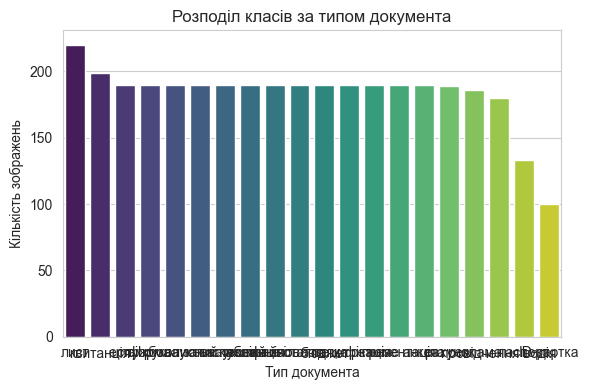


Співвідношення найбільшого до найменшого класу: 2.2x


In [15]:
counts = df_clean[TARGET].value_counts()
props = df_clean[TARGET].value_counts(normalize=True).round(3)
print(counts)
print()
print(props)

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)
plt.title('Розподіл класів за типом документа')
plt.ylabel('Кількість зображень')
plt.xlabel('Тип документа')
plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=120)
plt.show()

ratio = counts.max() / counts.min()
print(f"\nСпіввідношення найбільшого до найменшого класу: {ratio:.1f}x")

**Висновок:** дисбаланс помірний (~2.2x між найбільшим класом «лист», 220, і найменшим «ID-картка», 100), не критичний, але достатній, щоб надалі використовувати `stratify=y` при розбитті та не покладатися лише на accuracy як метрику в Лаб.2 (тим паче за 20 класів).

## 3.6. Візуальний EDA (5 інформативних візуалізацій)

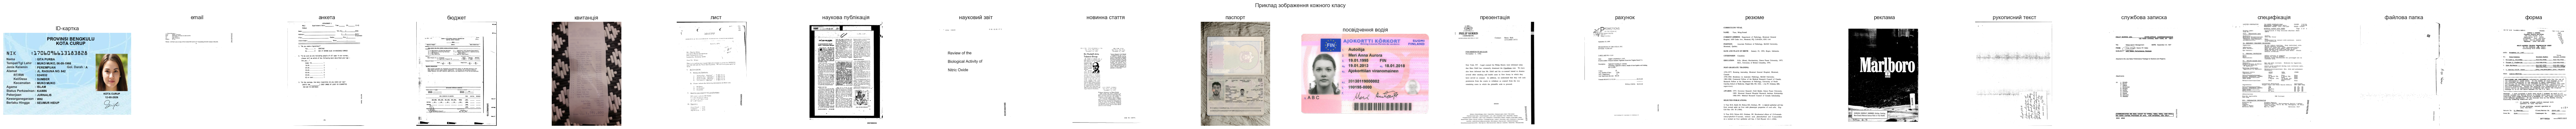

In [16]:
# 1) Приклади зображень кожного класу
classes = sorted(df_clean[TARGET].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(4*len(classes), 4))
for ax, cls in zip(axes, classes):
    sample_path = df_clean.loc[df_clean[TARGET] == cls, 'filepath'].iloc[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Приклад зображення кожного класу')
plt.tight_layout()
plt.savefig('fig_examples.png', dpi=120)
plt.show()

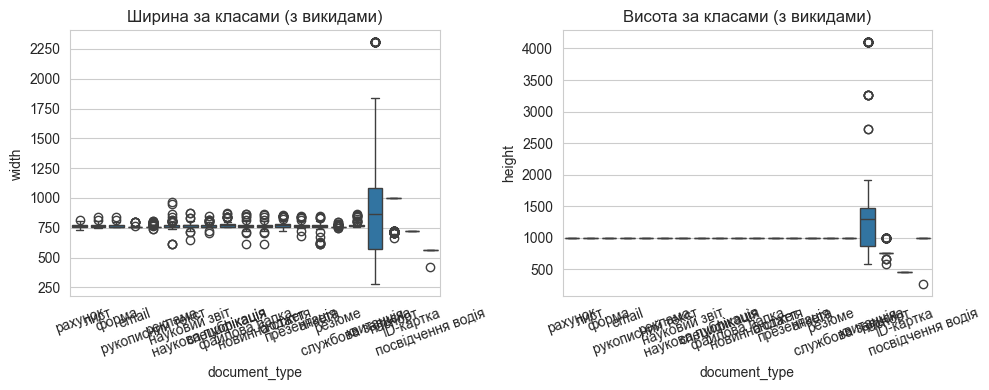

In [17]:
# 2) Розподіл ширини і висоти зображень (boxplot) - показує викиди
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=TARGET, y='width', data=df_clean, ax=axes[0])
axes[0].set_title('Ширина за класами (з викидами)')
axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(x=TARGET, y='height', data=df_clean, ax=axes[1])
axes[1].set_title('Висота за класами (з викидами)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('fig_dims_boxplot.png', dpi=120)
plt.show()

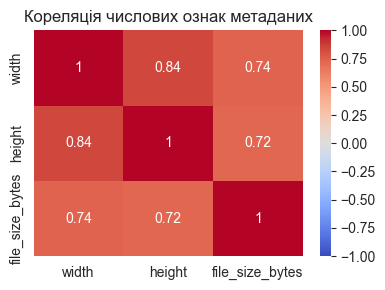

In [18]:
# 3) Кореляційна матриця числових метаданих
plt.figure(figsize=(4, 3))
sns.heatmap(df_clean[['width', 'height', 'file_size_bytes']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Кореляція числових ознак метаданих')
plt.tight_layout()
plt.savefig('fig_corr.png', dpi=120)
plt.show()

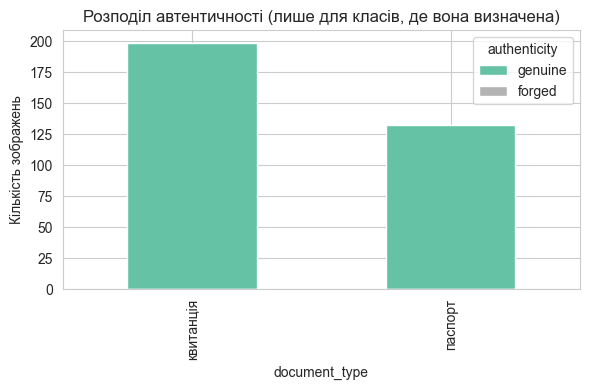

authenticity   genuine  forged
document_type                 
квитанція          199       0
паспорт            133       0

Частка підроблених у кожному з цих класів:
document_type
квитанція    0.0
паспорт      0.0
dtype: float64

УВАГА: у поточному реальному наборі немає жодного прикладу 'forged' (відкриті джерела CORD/SROIE містять лише справжні чеки). Бінарна задача автентичності на цьому наборі вироджена (один клас).


In [19]:
# 4) Розподіл автентичності серед класів, де вона визначена
auth_df = df_clean[df_clean[AUTH_COLUMN].isin(['genuine', 'forged'])]
auth_counts = auth_df.groupby([TARGET, AUTH_COLUMN]).size().unstack(fill_value=0)
for col in ['genuine', 'forged']:
    if col not in auth_counts.columns:
        auth_counts[col] = 0
auth_counts = auth_counts[['genuine', 'forged']]

auth_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='Set2')
plt.title('Розподіл автентичності (лише для класів, де вона визначена)')
plt.ylabel('Кількість зображень')
plt.tight_layout()
plt.savefig('fig_auth_balance.png', dpi=120)
plt.show()
print(auth_counts)
print("\nЧастка підроблених у кожному з цих класів:")
print((auth_counts['forged'] / auth_counts.sum(axis=1)).round(3))
if (auth_counts['forged'] == 0).all():
    print("\nУВАГА: у поточному реальному наборі немає жодного прикладу 'forged' "
          "(відкриті джерела CORD/SROIE містять лише справжні чеки). "
          "Бінарна задача автентичності на цьому наборі вироджена (один клас).")

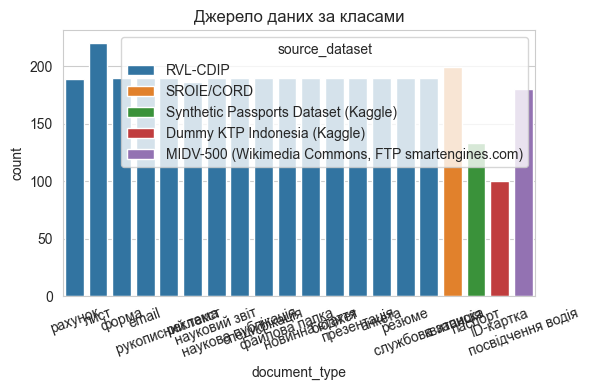

In [20]:
# 5) Розподіл джерел датасету за класами
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, hue='source_dataset', data=df_clean)
plt.title('Джерело даних за класами')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig_sources.png', dpi=120)
plt.show()

**Інтерпретація 5 графіків (реальні дані, 20 класів):**
1. *Баланс класів* — «лист» найбільший (220), «ID-картка» — найменший (100); дисбаланс помірний (~2.2x між найбільшим і найменшим), значно менший за 20-класним планом, ніж раніше на 4-класному підмножині.
2. *Приклади зображень* — 20 класів чітко розпадаються на дві групи за джерелом і компонуванням: 16 класів RVL-CDIP — однорідні скановані документи у відтінках сірого (рахунок, лист, форма, email тощо); квитанція (CORD), паспорт, ID-картка, посвідчення водія — кольорові фотографії реальних/синтетичних документів довільної роздільної здатності.
3. *Boxplot розмірів* — 682 «викиди» за IQR у розділі 3.4 зосереджені майже виключно в 4 «фотографічних» класах (квитанція 200, посвідчення водія 180, паспорт 111, ID-картка 100) плюс поодинокі викиди в кількох RVL-CDIP класах — усі легітимні реальні зображення різної роздільної здатності, а не помилка.
4. *Кореляція метаданих* — на всіх 20 класах `width`/`height` корелюють помірно (r≈0.84), із `file_size_bytes` — r≈0.72-0.74. Кореляція трохи нижча, ніж на підмножині з 3-4 класів, бо тепер набір поєднує дуже різні типи зображень (однорідні скани й фотографії довільного розміру) з різних 5 джерел.
5. *Автентичність* — з 3682 зображень 3349 (усі 16 класів RVL-CDIP + посвідчення водія + ID-картка) не мають визначеної автентичності (NaN — не застосовується для цих класів), а 333 (усі квитанції + усі паспорти) позначені `genuine`. Жодного `forged` прикладу немає — відкриті джерела не містять підроблених документів, тому бінарна підзадача автентичності наразі вироджена.</cell id="798491c2">

## 3.7. Формування X та y

In [21]:
from sklearn.preprocessing import LabelEncoder

# --- Основна задача: тип документа (усі очищені дані) ---
def load_flatten(path, size=IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert('L').resize(size)
        return np.asarray(im, dtype=np.float32).flatten()

X = np.stack([load_flatten(p) for p in df_clean['filepath']])
le_type = LabelEncoder()
y = le_type.fit_transform(df_clean[TARGET])

print("X shape:", X.shape, " y shape:", y.shape)
print("\nВідповідність код -> клас (document_type):")
for code_, label in enumerate(le_type.classes_):
    print(f"  {code_} -> {label}")

# --- Допоміжна задача: автентичність (лише підмножина класів) ---
auth_subset = df_clean[df_clean[AUTH_COLUMN].isin(['genuine', 'forged'])].copy()
X_auth = np.stack([load_flatten(p) for p in auth_subset['filepath']])
le_auth = LabelEncoder()
y_auth = le_auth.fit_transform(auth_subset[AUTH_COLUMN])
print("\nX_auth shape:", X_auth.shape, " y_auth shape:", y_auth.shape)
print("Відповідність код -> автентичність:")
for code_, label in enumerate(le_auth.classes_):
    print(f"  {code_} -> {label}")

X shape: (3677, 1024)  y shape: (3677,)

Відповідність код -> клас (document_type):
  0 -> ID-картка
  1 -> email
  2 -> анкета
  3 -> бюджет
  4 -> квитанція
  5 -> лист
  6 -> наукова публікація
  7 -> науковий звіт
  8 -> новинна стаття
  9 -> паспорт
  10 -> посвідчення водія
  11 -> презентація
  12 -> рахунок
  13 -> резюме
  14 -> реклама
  15 -> рукописний текст
  16 -> службова записка
  17 -> специфікація
  18 -> файлова папка
  19 -> форма



X_auth shape: (332, 1024)  y_auth shape: (332,)
Відповідність код -> автентичність:
  0 -> genuine


**Чому саме так:** k-NN (Лаб.2) працює з фіксованим числовим вектором ознак, тому кожне зображення приводиться до одного розміру (32×32, відтінки сірого) і розгортається у вектор із 1024 чисел. Це найпростіший базовий варіант ознак; надалі (за потреби) його можна замінити на менш вимогливі до розмірності ознаки (наприклад, гістограми або ознаки з попередньо навченої мережі).

## 3.8. Train / Test split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Тип документа: X_train:", X_train.shape, " X_test:", X_test.shape)
print("Частки класів у train:", np.round(np.bincount(y_train) / len(y_train), 3))
print("Частки класів у test: ", np.round(np.bincount(y_test) / len(y_test), 3))

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_auth, y_auth, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_auth
)
print("\nАвтентичність: X_train:", Xa_train.shape, " X_test:", Xa_test.shape)
print("Частка forged у train:", round(ya_train.mean(), 3), " у test:", round(ya_test.mean(), 3))

Тип документа: X_train: (2941, 1024)  X_test: (736, 1024)
Частки класів у train: [0.027 0.052 0.052 0.052 0.054 0.06  0.052 0.052 0.052 0.036 0.049 0.052
 0.051 0.052 0.051 0.052 0.052 0.052 0.052 0.052]
Частки класів у test:  [0.027 0.052 0.052 0.052 0.054 0.06  0.052 0.052 0.052 0.037 0.049 0.052
 0.052 0.052 0.05  0.052 0.052 0.052 0.052 0.052]

Автентичність: X_train: (265, 1024)  X_test: (67, 1024)
Частка forged у train: 0.0  у test: 0.0


`stratify=y` зберігає пропорції класів (в т.ч. рідкісного класу «лист» і рідкісного класу «forged») в обох вибірках — без цього при такому дисбалансі test міг би взагалі не отримати жодного прикладу міноритарного класу.

## 3.9. Масштабування ознак (без data leakage)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ТІЛЬКИ на train
X_test_scaled = scaler.transform(X_test)          # transform без повторного fit

scaler_auth = StandardScaler()
Xa_train_scaled = scaler_auth.fit_transform(Xa_train)
Xa_test_scaled = scaler_auth.transform(Xa_test)

print("Перевірка: середнє X_train_scaled ~ 0:", round(X_train_scaled.mean(), 4))
print("Перевірка: std X_train_scaled ~ 1:", round(X_train_scaled.std(), 4))
print("\nКРИТИЧНО: scaler.fit() викликано лише на X_train; X_test лише transform() — це виключає data leakage.")

Перевірка: середнє X_train_scaled ~ 0: -0.0
Перевірка: std X_train_scaled ~ 1: 1.0

КРИТИЧНО: scaler.fit() викликано лише на X_train; X_test лише transform() — це виключає data leakage.


## 3.10. Підсумкова підготовка даних

In [24]:
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)
np.save('Xa_train_scaled.npy', Xa_train_scaled)
np.save('Xa_test_scaled.npy', Xa_test_scaled)
np.save('ya_train.npy', ya_train)
np.save('ya_test.npy', ya_test)

print("Дані збережено. Підсумкові розміри:")
print(f"  Тип документа  - train {X_train_scaled.shape}, test {X_test_scaled.shape}")
print(f"  Автентичність  - train {Xa_train_scaled.shape}, test {Xa_test_scaled.shape}")
print("\nДані готові до побудови класифікатора k-NN у Лабораторній роботі №2.")

Дані збережено. Підсумкові розміри:
  Тип документа  - train (2941, 1024), test (736, 1024)
  Автентичність  - train (265, 1024), test (67, 1024)

Дані готові до побудови класифікатора k-NN у Лабораторній роботі №2.


## Висновок

1. **Який датасет досліджено та яка задача розпізнавання вирішується?**
   Реальний датасет із **20 класів** документів (повний план Лаб.0): 16 класів RVL-CDIP
   (рахунок 189, лист 220, форма/email/рукописний текст/реклама/науковий звіт/наукова
   публікація/специфікація/файлова папка/новинна стаття/бюджет/презентація/анкета/резюме/
   службова записка по 190 кожен), квитанція (200, CORD), паспорт (133, три Kaggle-датасети),
   ID-картка (100, Kaggle KTP), посвідчення водія (180, MIDV-500 через FTP). Усього 3682
   зображення. Усі дані завантажено повністю автоматично й відтворювано — код завантаження
   знаходиться прямо в notebook (Секція 0), а не виконаний окремим прихованим скриптом.
   Задача — багатокласова класифікація типу документа (20 класів); для класів
   «квитанція»/«паспорт» — додатково (наразі вироджена) бінарна класифікація автентичності.

2. **Які проблеми якості даних було виявлено?**
   5 зображень-дублікатів за вмістом файлу, 0 пошкоджених файлів, 0 пропусків у
   `source_dataset`/`width`/`height`, 682 «викиди» за IQR-методом за розмірами (зосереджені в
   4 «фотографічних» класах — квитанція, посвідчення водія, паспорт, ID-картка — природна
   різноманітність роздільної здатності реальних фотографій, а не помилка), помірний дисбаланс
   класів (~2.2x), і повна відсутність класу `forged` для автентичності (0/333). Окремо варто
   відзначити: 96 із 133 паспортних зображень (канадські) і всі 180 зображень посвідчення водія
   — це лише ОДНА синтетична особа/шаблон, відзнятий(а) під різними умовами, а не багато різних
   людей (обмеження безкоштовних зразків комерційних/академічних датасетів).

3. **Які перетворення виконано і чому?**
   Видалено дублікати зображень (загроза data leakage), зображення приведено до єдиного розміру
   32×32 у відтінках сірого й розгорнуто у вектор ознак для k-NN, дані розділені на train/test
   зі stratify (по всіх 20 класах), StandardScaler навчено лише на train. Пошкоджених файлів чи
   пропусків джерела не виявлено на цьому наборі.

4. **Які ознаки/закономірності виявилися найбільш цікавими?**
   `width` і `height` помірно корелюють (r≈0.84) і з `file_size_bytes` (r≈0.72-0.74) — це
   поєднання двох дуже різних груп джерел (однорідні скани RVL-CDIP vs фотографії довільного
   розміру для решти 4 класів) знижує загальну кореляцію порівняно з підмножиною з 3-4 класів.
   Ризик: модель може навчитись розрізняти «скан проти фото» замість реального типу документа.

5. **Чи є дисбаланс класів?**
   Помірний за типом документа (найбільший клас «лист», 220, у ~2.2 раза більший за найменший
   «ID-картка», 100) — набагато менший, ніж очікувалось би, з огляду на різні обсяги вихідних
   джерел. Автентичність повністю вироджена (100% genuine, 0% forged) — підзадача автентичності
   непридатна для навчання без реальних прикладів підробок.

6. **Чи готові дані до навчання класифікатора?**
   Для основної задачі (тип документа, 20 класів) — так, повний пайплайн відпрацьовано на
   реальних даних без помилок і без витоку даних, і notebook відтворюваний з нуля (Секція 0).
   Для допоміжної задачі (автентичність) — ні: є лише клас `genuine`, бінарний класифікатор не
   має чого навчатись без реальних `forged`-прикладів.

7. **Які ризики очікуються на наступному етапі (k-NN)?**
   (а) висока розмірність вектора ознак (1024) при 3682 прикладах на 20 класів — «прокляття
   розмірності» помножене на кількість класів; (б) сильна неоднорідність джерел (16
   сірошкальних скан-класів проти 4 кольорових фотографічних) може дозволити моделі
   «підглядати» джерело/тип зображення замість реального типу документа — варто перевірити це
   окремо в Лаб.2, можливо через ablation на серошкальному варіанті всіх класів; (в) і канадські
   паспорти, і фінське посвідчення водія — по одному синтетичному шаблону кожен, тож
   узагальнюваність цих двох класів на реальні (різні) документи варто трактувати з обережністю;
   (г) плоскі пікселі — грубе представлення зображення; (д) підзадачу автентичності доведеться
   відкласти або замінити на явно неінформативний baseline, доки не з'являться реальні приклади
   `forged`; (е) паспортні дані ліцензовано як CC BY-NC-ND 4.0 (некомерційне використання, без
   похідних робіт) — сумісно з навчальним проєктом, але обмежує подальше комерційне використання.

**Класи «посвідчення водія» та «ID-картка» (спроба розширення до плану Лаб.0):** ОБИДВА джерела
знайдено й успішно інтегровано — MIDV-500 (пряме FTP-з'єднання, реєстрація не потрібна) для
посвідчення водія та Kaggle KTP-датасет (MIT-ліцензія) для ID-картки. Жодний із 20 запланованих
класів не залишився без реальних даних.</cell id="870134d5">